In [1]:
from src.models.reservoir_computing_model import IPReservoirComputingModel
from src.models.lstm_model import LSTMRegressorModel
from src.evaluation_framework.evalutaion_framework import plot_large_residual_histograms
from utils.logger import get_logger
from utils.io import read_csv_file, read_json_file
from src.data_extractor.data_preparer import FlightDataPreparer, ModelType
import numpy as np

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logger = get_logger("Trainer")
DATA_SUFFIX = "extra_large"

train_df = read_csv_file(f"./data/datasets/opensky/preprocessed/train/data_{DATA_SUFFIX}.csv")
test_df = read_csv_file(f"./data/datasets/opensky/preprocessed/test/data_{DATA_SUFFIX}.csv")

display(train_df)
display(test_df)
data_preparer = FlightDataPreparer(target_column="velocity", window_size=12, required_length=100)

X_test_rc, y_test_rc, icao_list_test_rc = data_preparer.transform(test_df, model_type=ModelType.RESERVOIR_COMPUTING)
test_dataloader_lstm, n_features_test, icao_list_test_lstm = data_preparer.transform(test_df, model_type=ModelType.LSTM)

Successfully loaded CSV. Shape: (2227144, 16)
Successfully loaded CSV. Shape: (489969, 16)


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,1.125218,-0.553913,0.435131,0.438556,-0.352960,2.659376,5.368318,-0.897729,-0.930259,0.632723,-0.774378,1641168010,0,0,0,3c4582.0
1,1.142489,0.198391,0.461729,-0.907274,0.088551,0.014306,0.121706,0.912355,0.826150,-0.966279,0.257497,1641168010,0,0,0,4ca8e8.0
2,0.554535,0.563995,0.443059,0.680354,0.922952,-0.035045,0.056123,1.057598,1.105374,0.790564,0.612380,1641168020,0,0,0,06a30c.0
3,0.015515,0.212421,-0.640967,-0.018416,-1.726665,0.014306,-0.337373,-1.814572,-1.791349,-0.014924,0.999889,1641168020,0,0,0,a81032.0
4,0.084167,-0.009877,-0.688867,-0.019034,0.486855,0.262669,0.056123,0.621870,0.642402,-0.907072,0.420975,1641168020,0,0,0,a0d561.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227139,0.442401,0.461426,-0.624973,0.646332,0.754326,0.244152,0.056123,0.694492,0.664020,0.839570,0.543251,1641175190,0,0,0,a2c1bd.1
2227140,0.308457,-0.009877,-0.832641,-0.019034,0.428855,0.014306,0.121706,0.767113,0.773908,-0.999526,-0.030791,1641175190,0,0,0,a11d47.3
2227141,-0.517281,-0.009877,1.728771,-0.019034,0.471152,0.014306,0.974280,-0.427507,-0.368208,0.252422,0.967617,1641175190,0,0,0,781b94.0
2227142,0.274200,-0.009877,1.784340,-0.019034,-0.115989,0.014306,-0.927617,-0.129760,-0.159240,-0.987530,-0.157432,1641175190,0,0,0,781157.2


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,-3.127935,-0.315133,-0.072904,-0.171713,-0.905581,0.014306,-0.730869,-1.266282,-1.249115,-0.553753,-0.832681,1641168020,0,0,0,e48003.0
1,-3.127148,0.630988,-0.073944,-0.428996,0.412256,-1.175492,-2.370435,-0.810584,-0.768129,-0.647648,0.761939,1641168020,0,0,0,e49329.0
2,0.217623,0.815193,-0.475728,-0.381478,0.873636,0.014306,0.056123,0.912355,0.927031,-0.454672,0.890659,1641168020,0,0,0,ad7760.0
3,0.249408,-0.482083,-0.823224,-0.474595,0.119701,-0.005107,0.056123,1.273646,1.281915,-0.740415,-0.672150,1641168020,0,0,0,ad5658.0
4,0.190320,-0.197598,-0.839459,-0.427605,-0.744223,-0.086250,-1.649026,-1.175505,-1.171652,-0.930797,-0.365536,1641168020,0,0,0,ac58b9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489964,0.568851,0.004412,-0.395118,1.103347,1.863746,0.014306,0.121706,0.549249,0.494684,0.999935,0.011400,1641175190,0,0,0,acf54f.1
489965,-3.894501,-0.173730,2.421444,-0.333773,-1.198772,1.665036,0.121706,-1.633019,-1.613006,-0.914013,-0.405685,1641175190,0,1,0,c818da.1
489966,-2.292795,-0.736216,0.034660,-0.335029,0.550138,0.014306,0.056123,0.912355,1.056735,-0.529179,-0.848510,1641175190,0,0,0,e07246.0
489967,-4.153812,-0.028294,2.416199,0.208550,-1.843287,0.582410,-0.075042,-1.420602,-1.405840,0.996428,-0.084443,1641175190,0,0,0,c805a0.2


In [5]:
rc_model = IPReservoirComputingModel.load_model("hpt_rc", "1777324445")
y_pred_rc = rc_model.predict(X_test_rc)
lstm_model = LSTMRegressorModel.load_model("lstm_test", "1777325940")
y_true_lstm, y_pred_lstm = lstm_model.predict(test_dataloader_lstm)

Successfully loaded JSON as a dictionary.
Successfully loaded NPY from ./data/models\hpt_rc\1777324445\readout_weights.npy. Shape: (200, 1)
Successfully loaded NPY from ./data/models\hpt_rc\1777324445\readout_bias.npy. Shape: (1,)
Successfully loaded JSON as a dictionary.
Successfully loaded PyTorch model from ./data/models\lstm_test\1777325940\model.pth to cuda


In [6]:
y_pred_flattened = np.concatenate([y[12:] for y in y_pred_rc])
y_test_rc_flattened = np.concatenate([y[12:] for y in y_test_rc])

Algorithm            | Mean Error      | Std Dev        
-------------------------------------------------------
rc                   | 0.0007          | 0.1102         
lstm                 | 0.0156          | 0.1123         


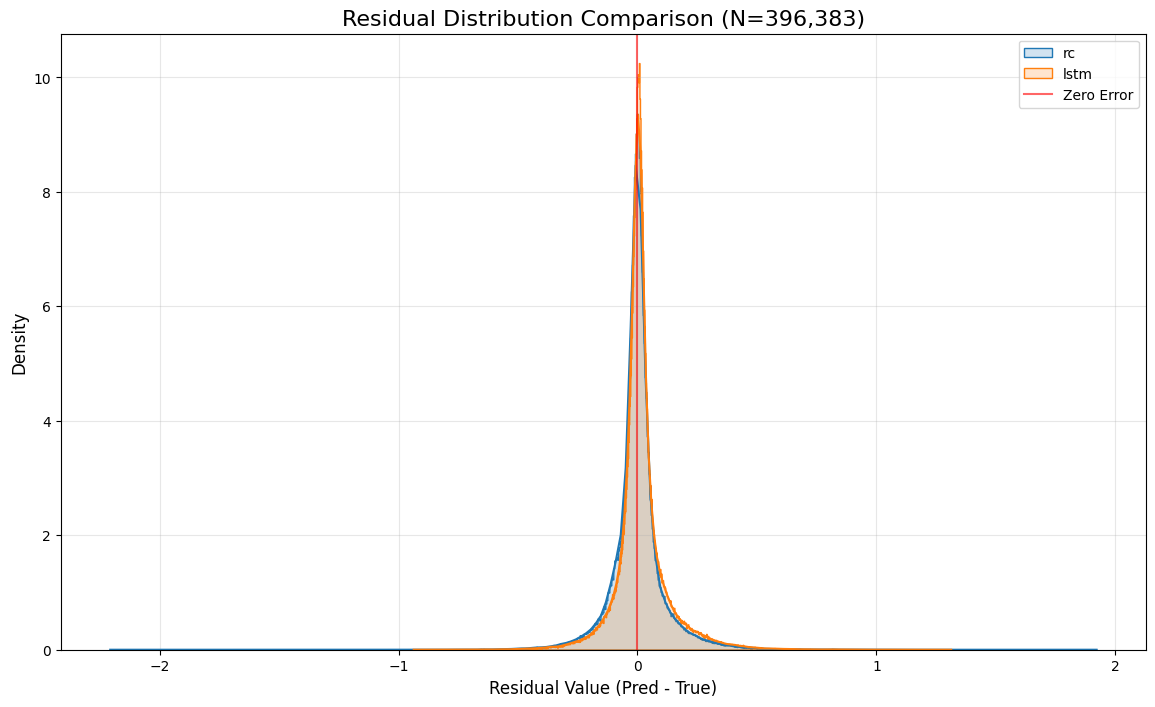

In [7]:
d = {
    "rc": y_pred_flattened,
    "lstm": y_pred_lstm
}
plot_large_residual_histograms(y_true_lstm, d, n_bins=1000)

In [8]:
inverse_transform_dict = read_json_file(f"./data/datasets/opensky/metadata/transformations/dataset_{DATA_SUFFIX}_transformations.json")
mean_vel = inverse_transform_dict["velocity"]["mean"]
std_vel = inverse_transform_dict["velocity"]["std"]

Successfully loaded JSON as a dictionary.


In [9]:
from src.evaluation_framework.evalutaion_framework import map_predictions_to_icao, plot_icao_results


--- Statistics for ICAO: ac58b9.0 ---
Naive -> MSE: 598.3754, MAPE: 32.78%, R2: -3.64
rc -> MSE: 277.2170, MAPE: 23.70%, R2: 0.66
lstm -> MSE: 380.5017, MAPE: 30.04%, R2: 0.54


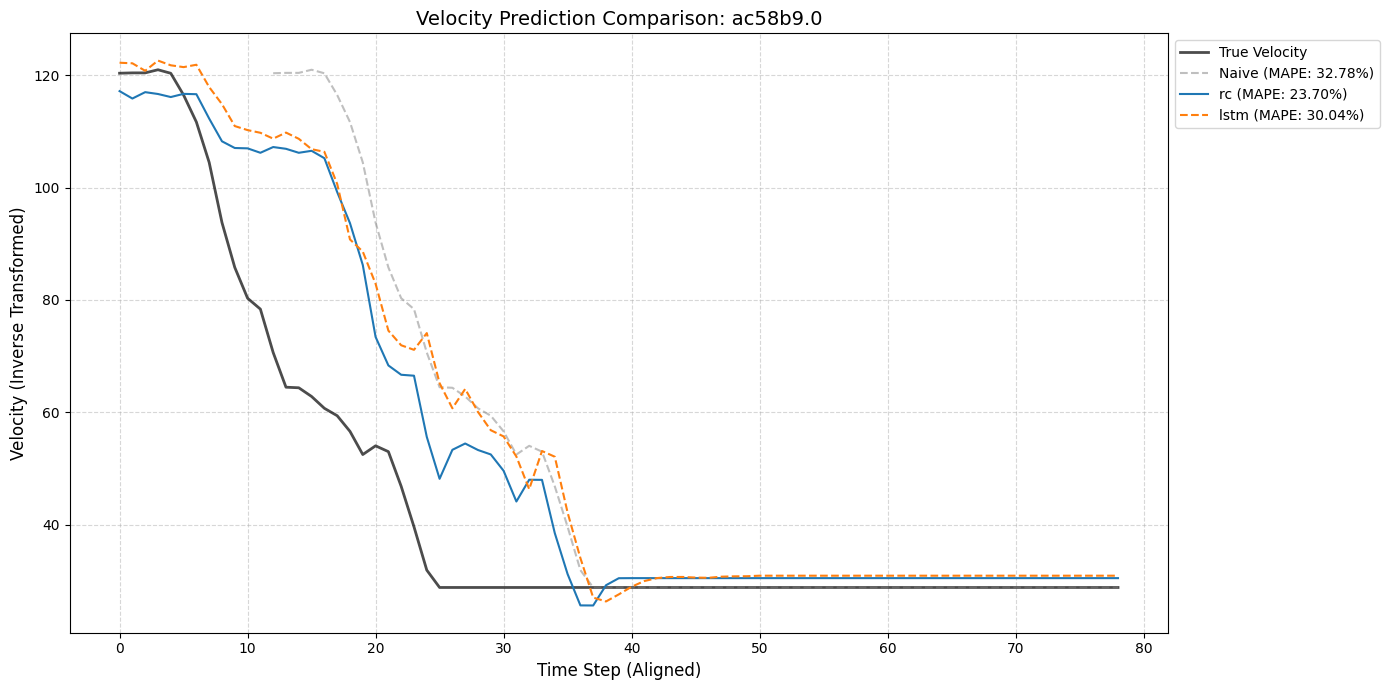

In [10]:
true_map = map_predictions_to_icao(
    y_true_lstm, 
    icao_list_test_lstm, 
    ModelType.LSTM,
    mean=mean_vel, 
    std=std_vel
)

rc_results_mapped = map_predictions_to_icao(
    y_pred_rc, 
    icao_list_test_rc, 
    ModelType.RESERVOIR_COMPUTING, 
    window_size=12,
    mean=mean_vel, 
    std=std_vel
)

lstm_results_mapped = map_predictions_to_icao(
    y_pred_lstm, 
    icao_list_test_lstm, 
    ModelType.LSTM, 
    mean=mean_vel, 
    std=std_vel
)

models_to_compare = {
    "rc": rc_results_mapped,
    "lstm": lstm_results_mapped
}

plot_icao_results(icao_list_test_rc[100], true_map, models_to_compare, window_size=12)

In [17]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def get_detailed_rankings(model_name, model_map_dict, true_map):
    predictions_dict = model_map_dict.get(model_name.lower())
    
    if not predictions_dict:
        print(f"Error: Model '{model_name}' not found.")
        return None

    stats = []
    for icao, y_pred in predictions_dict.items():
        if icao in true_map:
            y_true = true_map[icao].flatten()
            y_p = y_pred.flatten()
            
            min_len = min(len(y_true), len(y_p))
            y_t_clip = y_true[:min_len]
            y_p_clip = y_p[:min_len]
            
            mape = mean_absolute_percentage_error(y_t_clip, y_p_clip) * 100
            mse = mean_squared_error(y_t_clip, y_p_clip)
            r2 = r2_score(y_t_clip, y_p_clip)
            
            stats.append({
                "icao24": icao,
                "MAPE (%)": round(mape, 4),
                "MSE": round(mse, 4),
                "R2": round(r2, 4)
            })

    df = pd.DataFrame(stats)

    best_mape = df.sort_values(by="MAPE (%)", ascending=True).reset_index(drop=True)
    best_mse = df.sort_values(by="MSE", ascending=True).reset_index(drop=True)
    best_r2 = df.sort_values(by="R2", ascending=False).reset_index(drop=True)

    return best_mape, best_mse, best_r2

In [18]:

mape_list, mse_list, r2_list = get_detailed_rankings("lstm", models_to_compare, true_map)

print("--- BEST MODELS BY MAPE ---")
print(mape_list[["icao24", "MAPE (%)"]].head(5))

print("\n--- ICAOs SORTED BY MSE (Lowest Error First) ---")
print(mse_list[["icao24", "MSE"]].head(5))

print("\n--- ICAOs SORTED BY R2 (Best Fit First) ---")
print(r2_list[["icao24", "R2"]].head(5))

--- BEST MODELS BY MAPE ---
     icao24  MAPE (%)
0  c030bb.0    0.2065
1  c03f85.1    0.2190
2  c058b4.1    0.2302
3  adf5e2.1    0.2334
4  acab11.1    0.2432

--- ICAOs SORTED BY MSE (Lowest Error First) ---
     icao24     MSE
0  ac4e92.1  0.3067
1  c030bb.0  0.3855
2  adf5e2.1  0.4059
3  acab11.1  0.4618
4  accd8c.1  0.5197

--- ICAOs SORTED BY R2 (Best Fit First) ---
     icao24      R2
0  ad8bed.0  0.9951
1  ad5460.1  0.9950
2  ad9712.1  0.9948
3  ac793f.1  0.9943
4  adea26.0  0.9942



--- Statistics for ICAO: ad8bed.0 ---
Naive -> MSE: 190.4899, MAPE: 6.22%, R2: 0.97
rc -> MSE: 48.9865, MAPE: 3.55%, R2: 0.99
lstm -> MSE: 27.2654, MAPE: 2.25%, R2: 1.00


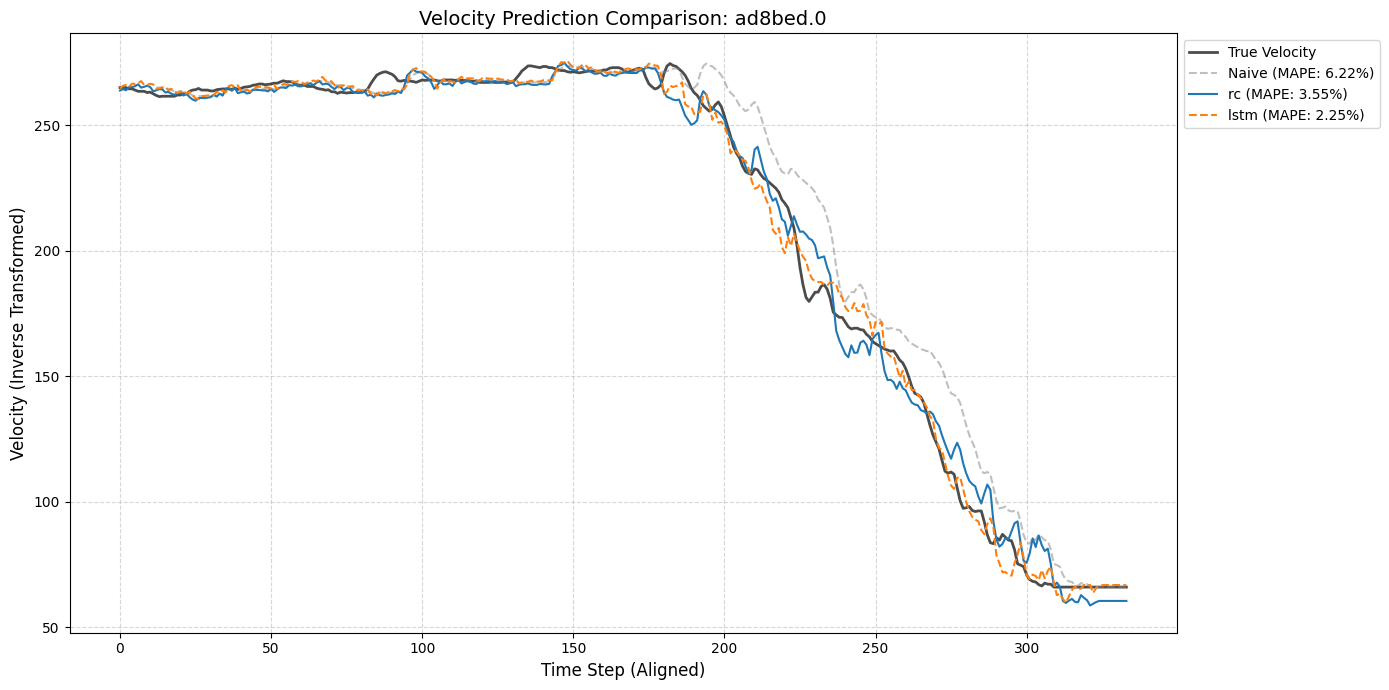

In [13]:
plot_icao_results("ad8bed.0", true_map, models_to_compare, window_size=12)


--- Statistics for ICAO: ad5460.1 ---
Naive -> MSE: 152.5292, MAPE: 7.60%, R2: 0.97
rc -> MSE: 34.8469, MAPE: 4.18%, R2: 0.99
lstm -> MSE: 25.8056, MAPE: 3.62%, R2: 0.99


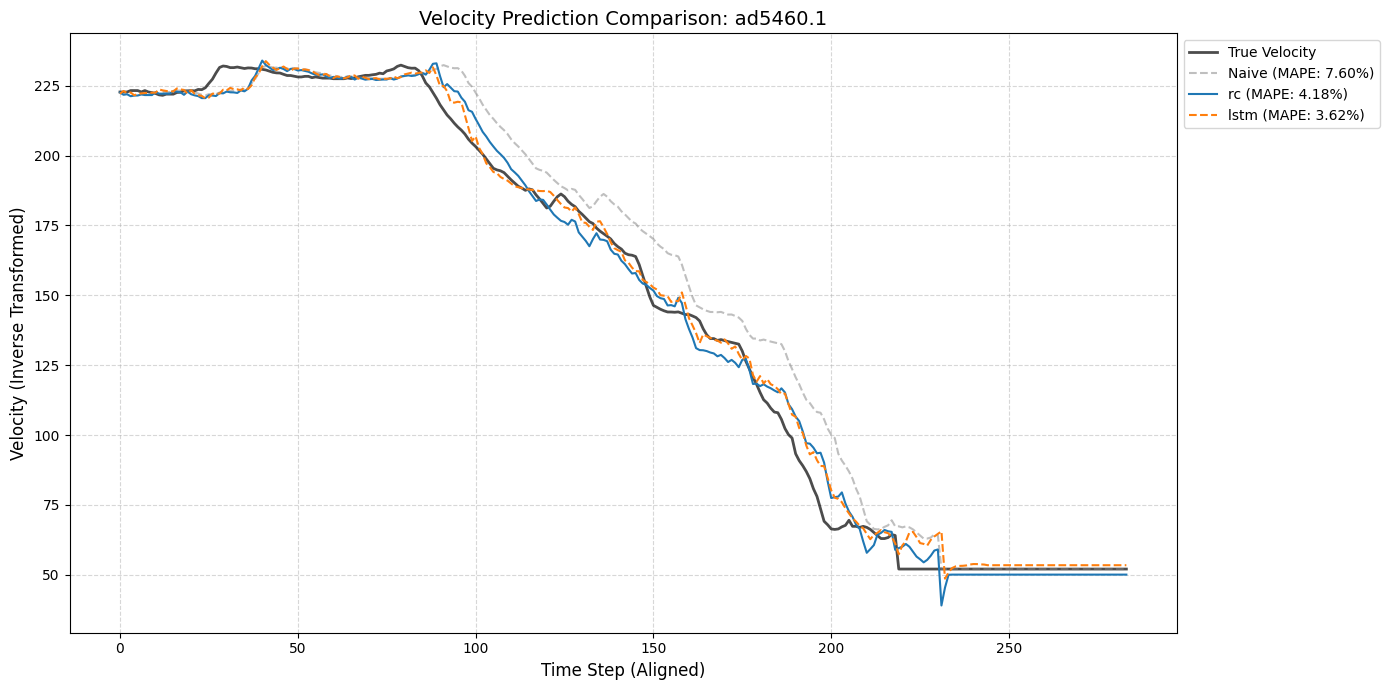

In [14]:
plot_icao_results("ad5460.1", true_map, models_to_compare, window_size=12)


--- Statistics for ICAO: ad9712.1 ---
Naive -> MSE: 341.5550, MAPE: 10.21%, R2: 0.94
rc -> MSE: 69.6812, MAPE: 5.74%, R2: 0.99
lstm -> MSE: 33.8524, MAPE: 3.36%, R2: 0.99


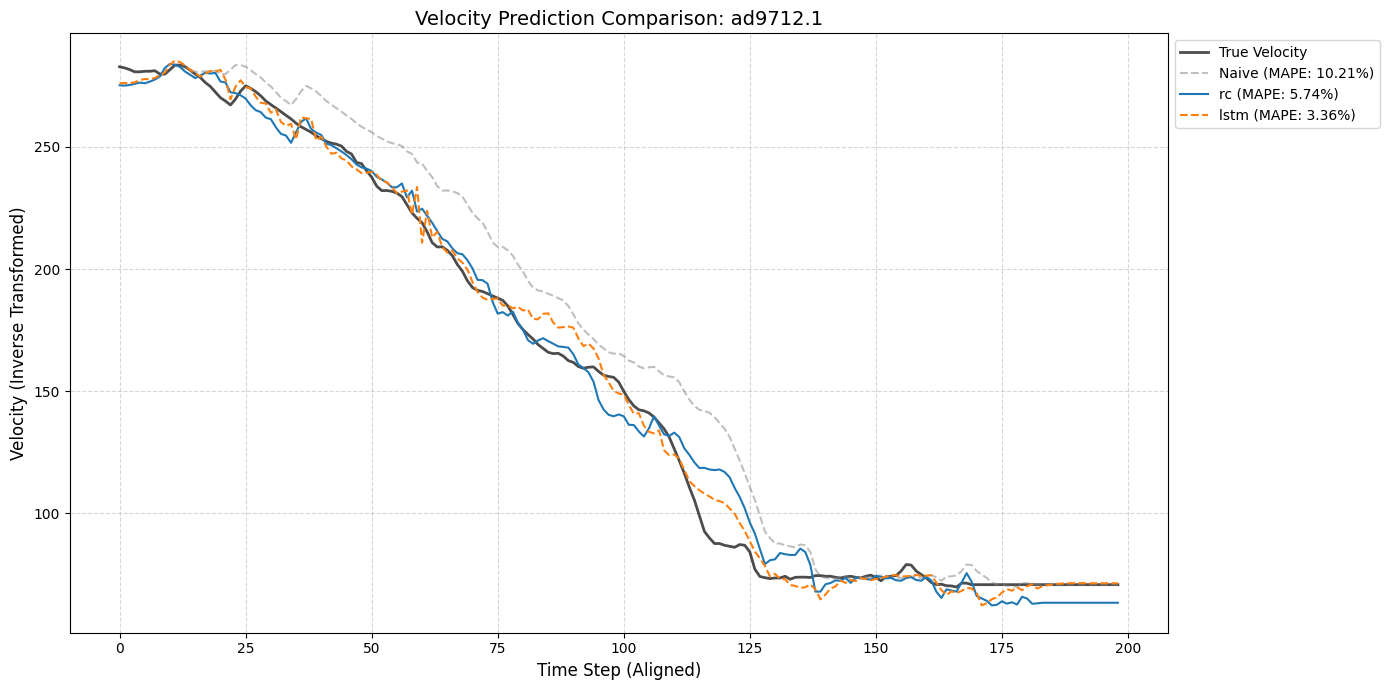

In [15]:
plot_icao_results("ad9712.1", true_map, models_to_compare, window_size=12)


--- Statistics for ICAO: c058b4.1 ---
Naive -> MSE: 0.4096, MAPE: 0.18%, R2: 0.55
rc -> MSE: 0.6582, MAPE: 0.28%, R2: 0.27
lstm -> MSE: 0.5342, MAPE: 0.23%, R2: 0.40


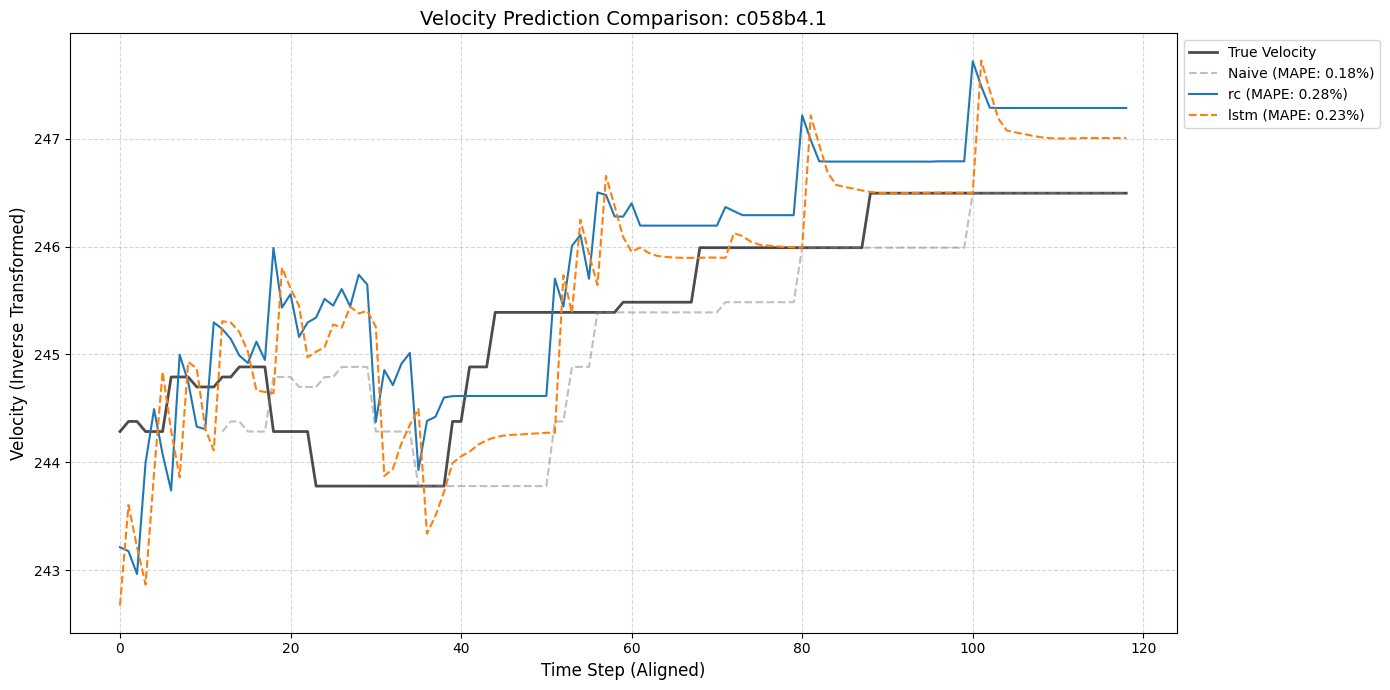

In [16]:
plot_icao_results("c058b4.1", true_map, models_to_compare, window_size=12)